# Proyecto 5 — Recuperación y evaluación en RAG

Cuaderno técnico. Se completa de forma progresiva a lo largo de los hitos.

**Pregunta técnica:** comparar recuperación léxica (BM25), densa (embeddings) e híbrida (RRF) sobre un corpus de 100+ documentos y 30+ consultas, midiendo P@k, R@k, MRR y nDCG, más latencia y memoria, y analizando qué tipos de consulta fallan en cada método.

## 1. Datos: corpus y consultas (Hito 2)

El corpus (`data/corpus/corpus.jsonl`) reúne 595 fragmentos de 40 artículos de Wikipedia en español sobre PLN, recuperación de información y aprendizaje automático. Las consultas (`data/queries/queries.jsonl`) son 54, etiquetadas en tres tipos —**léxicas**, **semánticas** y **difíciles**— para analizar en qué casos gana cada método de recuperación. Detalle y procedencia en [`docs/datos.md`](../docs/datos.md).

Generar los datos desde cero: `python scripts/fetch_sources.py` (descarga los artículos) y `python scripts/prepare_corpus.py` (limpia y trocea).

In [1]:
import json
from pathlib import Path

DATA = Path("..") / "data"


def load_jsonl(path):
    with open(path, encoding="utf-8") as f:
        return [json.loads(line) for line in f if line.strip()]


corpus = load_jsonl(DATA / "corpus" / "corpus.jsonl")
queries = load_jsonl(DATA / "queries" / "queries.jsonl")

print(f"Fragmentos en el corpus: {len(corpus)}")
print(f"Consultas de evaluación: {len(queries)}")
print("\nEjemplo de fragmento:")
print(corpus[0])

Fragmentos en el corpus: 595
Consultas de evaluación: 54

Ejemplo de fragmento:
{'doc_id': 'analisis_grupos__c00', 'source_id': 'analisis_grupos', 'title': 'Análisis de grupos', 'text': 'Análisis de grupos o agrupamiento es la tarea de agrupar objetos por similitud, en grupos o conjuntos de manera que los miembros del mismo grupo tengan características similares. Es la tarea principal de la minería de datos exploratoria y es una técnica común en el análisis de datos estadísticos. Además es utilizada en múltiples campos comoː aprendizaje automático reconocimiento de patrones análisis de imágenes búsqueda y recuperación de información bioinformática compresión de datos computación gráfica. El análisis de grupos es un problema, es un planteamiento general, y existen miles\u200b de algoritmos que lo resuelven, cada uno con sus propias características. Muchos algoritmos difieren significativamente en su idea de qué constituye un grupo y cómo encontrarlos eficientemente. El agrupamie'}


In [2]:
import pandas as pd

df = pd.DataFrame(corpus)
df["longitud"] = df["text"].str.len()

por_fuente = (
    df.groupby("source_id")
    .agg(titulo=("title", "first"), fragmentos=("doc_id", "count"), long_media=("longitud", "mean"))
    .sort_values("fragmentos", ascending=False)
)

print(
    f"Fuentes: {df['source_id'].nunique()} | "
    f"Fragmentos: {len(df)} | "
    f"Longitud media: {df['longitud'].mean():.0f} caracteres"
)
por_fuente.round(0)

Fuentes: 40 | Fragmentos: 595 | Longitud media: 784 caracteres


,titulo,fragmentos,long_media
source_id,,,
red_neuronal,Red neuronal artificial,82,796.0
analisis_grupos,Análisis de grupos,52,794.0
traduccion_automatica,Traducción automática,37,789.0
entropia,Entropía (información),28,784.0
aprendizaje_automatico,Aprendizaje automático,25,796.0
motor_busqueda,Motor de búsqueda,24,781.0
retropropagacion,Propagación hacia atrás,24,808.0
svm,Máquina de vectores de soporte,22,808.0
analisis_sentimiento,Análisis de sentimiento,20,795.0


In [3]:
import collections

conteo = collections.Counter(q["type"] for q in queries)
print("Consultas por tipo:", dict(conteo))

# Un ejemplo de cada tipo con sus fuentes relevantes.
for tipo in ["lexica", "semantica", "dificil"]:
    ejemplo = next(q for q in queries if q["type"] == tipo)
    print(f"\n[{tipo}] {ejemplo['query']}")
    print(f"   fuentes relevantes: {ejemplo['relevant_source_ids']}")

Consultas por tipo: {'lexica': 18, 'semantica': 18, 'dificil': 18}

[lexica] función de ranking Okapi BM25
   fuentes relevantes: ['bm25']

[semantica] cómo puntuar la pertinencia de un texto frente a las palabras buscadas
   fuentes relevantes: ['bm25']

[dificil] diferencia entre recuperación por palabras clave y búsqueda semántica
   fuentes relevantes: ['recuperacion_informacion', 'busqueda_semantica']


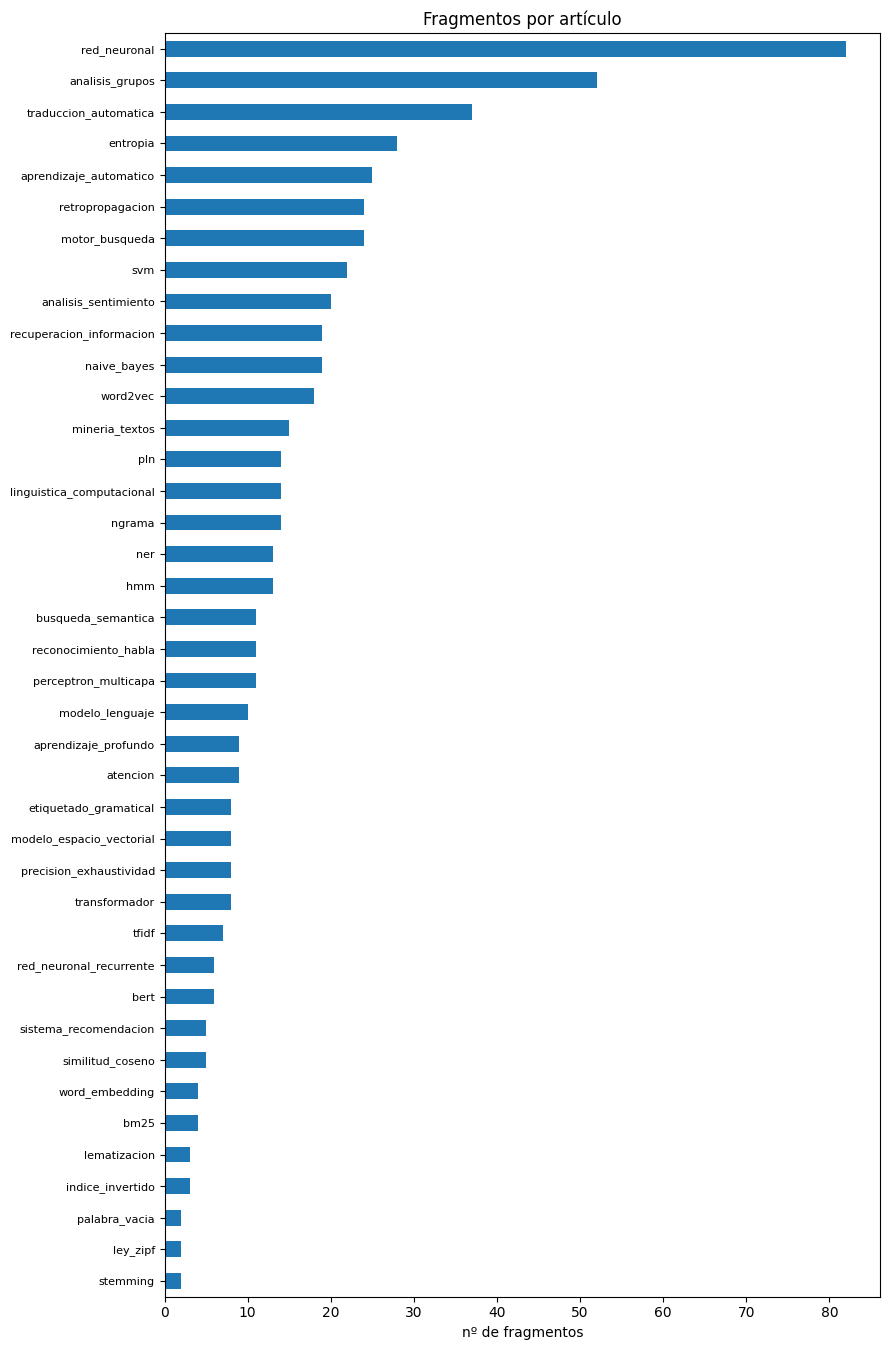

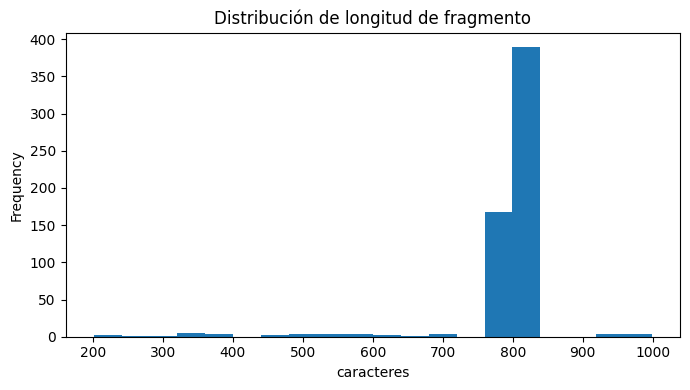

In [4]:
import matplotlib.pyplot as plt

orden = por_fuente["fragmentos"].sort_values()
fig, ax = plt.subplots(figsize=(9, max(6, 0.34 * len(orden))))
orden.plot.barh(ax=ax)
ax.set_title("Fragmentos por artículo")
ax.set_xlabel("nº de fragmentos")
ax.set_ylabel("")
ax.tick_params(axis="y", labelsize=8)
plt.tight_layout()
plt.show()

# Histograma de longitudes en una figura aparte.
fig, ax = plt.subplots(figsize=(7, 4))
df["longitud"].plot.hist(bins=20, ax=ax)
ax.set_title("Distribución de longitud de fragmento")
ax.set_xlabel("caracteres")
plt.tight_layout()
plt.show()

## 2. Línea base BM25 y métricas (Hito 3)

## 3. Recuperador denso (Hito 4)

## 4. Recuperador híbrido con RRF (Hito 5)

## 5. Evaluación comparativa y análisis de errores (Hito 6)

## 6. Conclusiones y limitaciones